In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [77]:
df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [79]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [80]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Text(0, 0.5, 'Frequency')

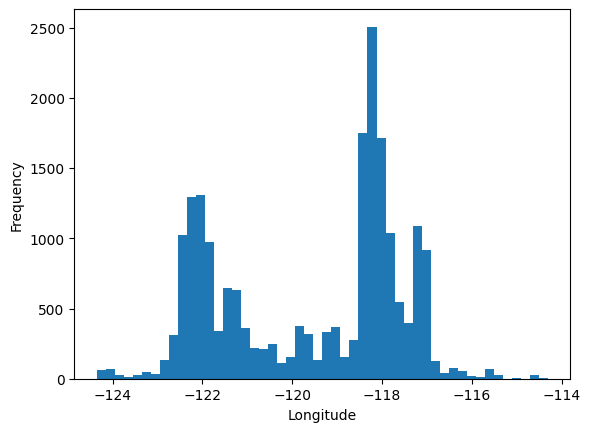

In [81]:
plt.hist(df['longitude'], bins=50)
plt.xlabel('Longitude')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

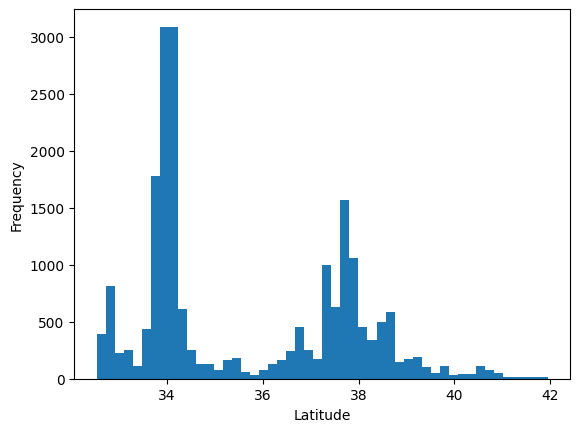

In [82]:
plt.hist(df['latitude'], bins=50)
plt.xlabel('Latitude')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

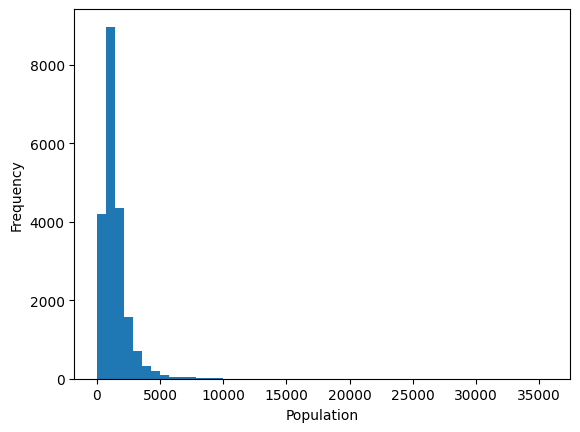

In [83]:
plt.hist(df['population'], bins=50)
plt.xlabel('Population')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

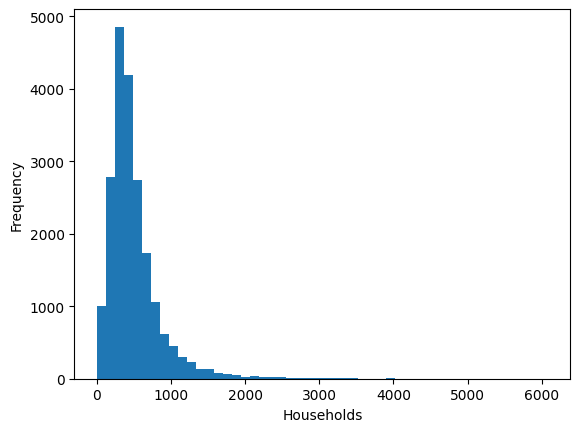

In [84]:
plt.hist(df['households'], bins=50)
plt.xlabel('Households')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

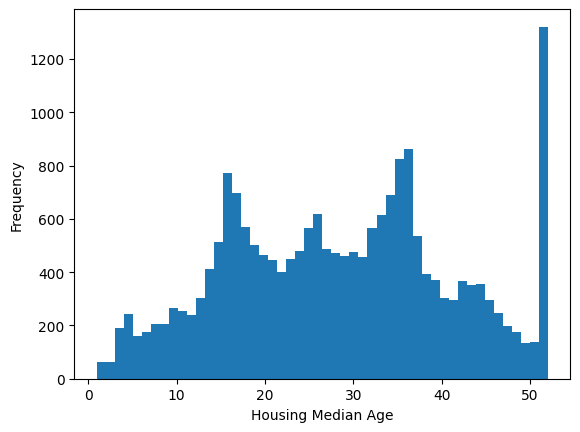

In [85]:
plt.hist(df['housing_median_age'], bins=50)
plt.xlabel('Housing Median Age')
plt.ylabel('Frequency')

In [86]:
df=df[df['housing_median_age']<50]

Text(0, 0.5, 'Frequency')

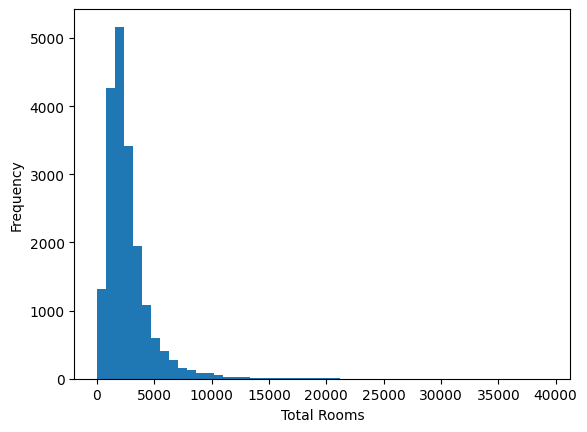

In [87]:
plt.hist(df['total_rooms'], bins=50)
plt.xlabel('Total Rooms')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

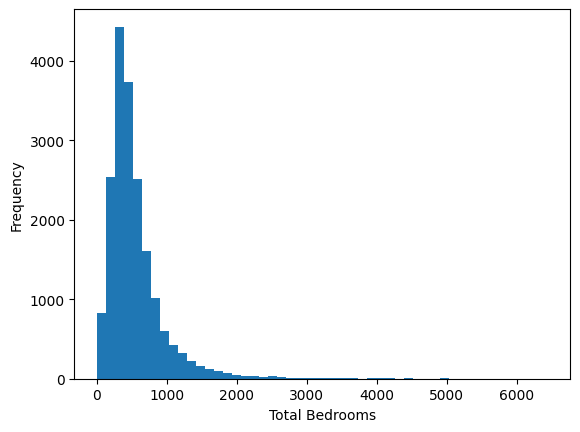

In [88]:
plt.hist(df['total_bedrooms'], bins=50)
plt.xlabel('Total Bedrooms')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

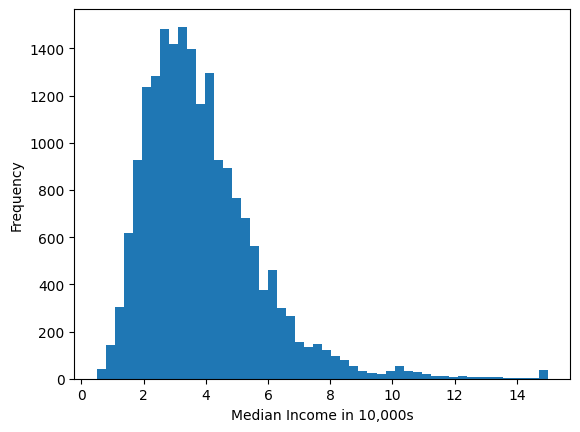

In [89]:
plt.hist(df['median_income'], bins=50)
plt.xlabel('Median Income in 10,000s')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

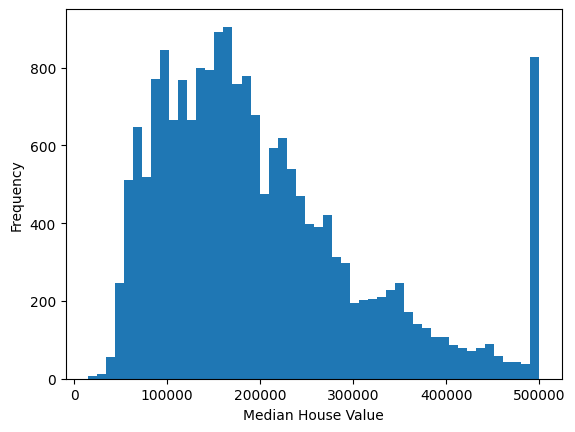

In [90]:
plt.hist(df['median_house_value'], bins=50)
plt.xlabel('Median House Value')
plt.ylabel('Frequency')

In [91]:
df = df[df['median_house_value'] < 500000]

In [92]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True, dtype=int)


In [93]:
correlation_matrix = df.corr()
correlation_matrix.style.background_gradient(cmap='coolwarm')


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
longitude,1.000000,-0.922575,-0.028302,0.034351,0.064148,0.089879,0.049674,-0.018244,-0.024153,-0.089629,0.005685,-0.415876,0.041445
latitude,-0.922575,1.000000,-0.057387,-0.026536,-0.064006,-0.106421,-0.069447,-0.073940,-0.170769,0.383604,-0.010682,0.310625,-0.162022
housing_median_age,-0.028302,-0.057387,1.000000,-0.374898,-0.331097,-0.278943,-0.310530,-0.200150,0.013918,-0.221741,0.001139,0.132842,0.037429
total_rooms,0.034351,-0.026536,-0.374898,1.000000,0.935422,0.860147,0.921922,0.222376,0.154073,0.026667,-0.006926,-0.001793,-0.013735
total_bedrooms,0.064148,-0.064006,-0.331097,0.935422,1.000000,0.880286,0.978778,0.020326,0.079743,-0.012189,-0.004425,-0.006141,0.004075
population,0.089879,-0.106421,-0.278943,0.860147,0.880286,1.000000,0.910745,0.039724,0.022854,-0.037719,-0.007974,-0.036333,-0.022072
households,0.049674,-0.069447,-0.310530,0.921922,0.978778,0.910745,1.000000,0.044770,0.100428,-0.047078,-0.006883,0.004188,0.005824
median_income,-0.018244,-0.073940,-0.200150,0.222376,0.020326,0.039724,0.044770,1.000000,0.664728,-0.227057,-0.008753,0.063615,-0.004256
median_house_value,-0.024153,-0.170769,0.013918,0.154073,0.079743,0.022854,0.100428,0.664728,1.000000,-0.502004,0.019641,0.112783,0.147250
ocean_proximity_INLAND,-0.089629,0.383604,-0.221741,0.026667,-0.012189,-0.037719,-0.047078,-0.227057,-0.502004,1.000000,-0.007535,-0.216713,-0.273162


Text(0, 0.5, 'Median House Value')

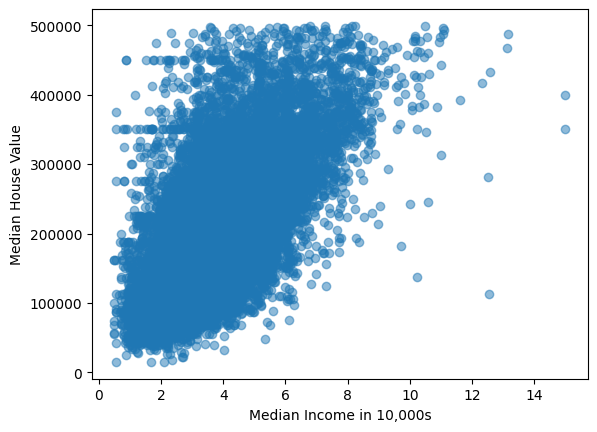

In [94]:
plt.plot(df['median_income'], df['median_house_value'], 'o', alpha=0.5  )
plt.xlabel('Median Income in 10,000s')
plt.ylabel('Median House Value')

Text(0, 0.5, 'Median House Value')

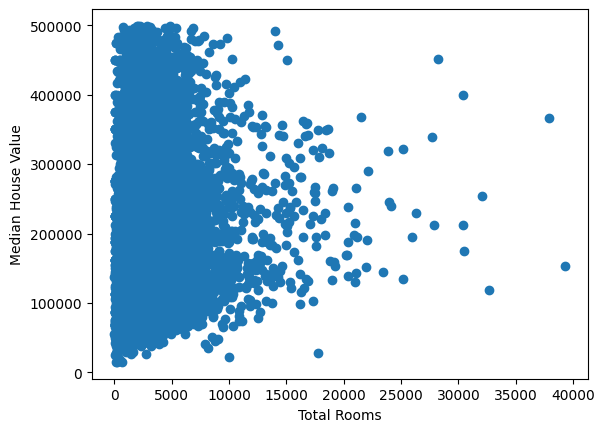

In [95]:
plt.plot( df['total_rooms'], df['median_house_value'], 'o')
plt.xlabel('Total Rooms')
plt.ylabel('Median House Value')

In [96]:
df['total_rooms_per_household'] = df['total_rooms'] / df['households']
df['population_per_household'] = df['population'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']


In [97]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [98]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

41956.95096333326
3257850932.204133
0.6339357864397832


In [99]:
import joblib
joblib.dump(model, 'house_model.joblib')
joblib.dump(imputer, 'data_imputer.joblib')

['data_imputer.joblib']